# Regression of VC grwoth on MPS (Local Projection)

In [1]:
# import necessary libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# load data
df = pd.read_csv(r"C:\Users\Ricardo\Documents\Projects\capstone_project\data\cleaned\local_projections_data\vc_LP_1_1.csv")

In [2]:
# columns of interest
y_col = "es_vc_growth"         # % pp growth of VC (q/q)
shock_col = "mps_25bp"         # 1 = 25 bp surprise at time t
real_gdp_col = "real_gdp_growth_l1"    # pp, lagged 1q (pre-shock control)
nasdaq_col = "nasdaq_ret_l1"    # pp, lagged 1q (pre-shock control)


In [ ]:
# Local Projection Model

H = 10 # forecast horizon inn quarters

rows = []

for h in range(H+1):
    # dependent variable is the future value: y_{t+h}
    y = df[y_col].shift(-h)

    #RHS is the same for all horizons (t or t-1 info)
    X = df[[shock_col, real_gdp_col]].copy()
    X = sm.add_constant(X)

    data = pd.concat([y, X], axis=1).dropna()
    
    # only estimate if enough data points; otherwise, store NaNs
    if len(data) < 10 : 
        rows.append({"horizon_q": h,
                     "beta_mps25": np.nan,
                     "beta_gdp": np.nan,
                     "se": np.nan,
                     "se_gdp": np.nan,
                     "p": np.nan,
                     "p_gdp": np.nan,
                     "ci90_low": np.nan,
                     "ci90_high": np.nan,
                     "N": len(data)})
        continue

    y_a = data[y_col]       # dependent variable After alignment
    X_a = data.drop(columns=[y_col])  # independent variables After alignment

    # OLS regression with HAC(Heteroskedasticity and Autocorrelation Consistent)(Newy-West) SEs; 
    res = sm.OLS(y_a, X_a).fit(cov_type="HAC", cov_kwds={"maxlags": max(h, 4)})


    b = res.params.get(shock_col, np.nan)   # coefficinent on shock

    se = res.bse.get(shock_col, np.nan)     # standard error on shock coefficient
    p = res.pvalues.get(shock_col, np.nan)  # p-value on shock coefficient
    lo = b - 1.645 * se if pd.notnull(b) and pd.notnull(se) else np.nan # 90% CI lower bound
    hi = b + 1.645 * se if pd.notnull(b) and pd.notnull(se) else np.nan # 90% CI upper bound

    # store results for current horzion h
    rows.append({"horizon_q": h,
                 "beta_mps25": b,
                 "se": se, 
                 "p": p, 
                 "ci90_low": lo,
                 "ci90_high": hi,
                 "N": int(res.nobs)
                 })

# create results DataFrame
irf = pd.DataFrame(rows)
# save results
irf.to_csv(r"C:\Users\Ricardo\Documents\Projects\capstone_project\results\local_projections\vc_LP_1_1_irf.csv", index=False)
irf



,horizon_q,beta_mps25,se,p,ci90_low,ci90_high,N
0,0,-10.349381,6.869741,1.319345e-01,-21.650105,0.951342,34
1,1,-4.632336,8.708145,5.947576e-01,-18.957233,9.692562,33
2,2,-7.792085,7.572190,3.034609e-01,-20.248338,4.664167,32
3,3,-14.343477,5.405397,7.965056e-03,-23.235354,-5.451599,31
4,4,-9.749948,4.220618,2.088394e-02,-16.692864,-2.807032,30
5,5,-11.150675,3.021768,2.241512e-04,-16.121482,-6.179867,29
6,6,-4.119720,5.499315,4.537768e-01,-13.166093,4.926652,28
7,7,-21.557860,4.178116,2.473340e-07,-28.430860,-14.684860,27
8,8,7.644915,3.525575,3.012703e-02,1.845344,13.444486,26
9,9,7.839687,3.474416,2.404531e-02,2.124274,13.555101,25


In [3]:
# Local Projection Model

H = 10 # forecast horizon in quarters

rows = []

for h in range(H+1):
    # dependent variable is the future value: y_{t+h}
    y = df[y_col].shift(-h)

    #RHS is the same for all horizons (t or t-1 info)
    X = df[[shock_col, real_gdp_col]].copy()
    X = sm.add_constant(X)

    data = pd.concat([y, X], axis=1).dropna()
    
    # only estimate if enough data points; otherwise, store NaNs
    if len(data) < 10 : 
        rows.append({"horizon_q": h,
                     "beta_mps25": np.nan,
                     "beta_gdp": np.nan,
                     "se": np.nan,
                     "se_gdp": np.nan,
                     "p": np.nan,
                     "p_gdp": np.nan,
                     "ci90_low": np.nan,
                     "ci90_high": np.nan,
                     "N": len(data)})
        continue


    y_a = data[y_col]       # dependent variable After alignment
    X_a = data.drop(columns=[y_col])  # independent variables After alignment

    # OLS regression with HAC(Heteroskedasticity and Autocorrelation Consistent)(Newy-West) SEs; 
    res = sm.OLS(y_a, X_a).fit(cov_type="HAC", cov_kwds={"maxlags": max(h, 4)})

    # Shock coefficient
    b = res.params.get(shock_col, np.nan)
    se = res.bse.get(shock_col, np.nan)
    p = res.pvalues.get(shock_col, np.nan)
    lo = b - 1.645 * se if pd.notnull(b) and pd.notnull(se) else np.nan
    hi = b + 1.645 * se if pd.notnull(b) and pd.notnull(se) else np.nan

    # GDP coefficient
    b_gdp = res.params.get(real_gdp_col, np.nan)
    se_gdp = res.bse.get(real_gdp_col, np.nan)
    p_gdp = res.pvalues.get(real_gdp_col, np.nan)

    # store results for current horizon h
    rows.append({"horizon_q": h,
                 "beta_mps25": b,
                 "beta_gdp": b_gdp,
                 "se": se,
                 "se_gdp": se_gdp,
                 "p": p,
                 "p_gdp": p_gdp,
                 "ci90_low": lo,
                 "ci90_high": hi,
                 "N": int(res.nobs)
                 })

# create results DataFrame
irf = pd.DataFrame(rows)

In [4]:
irf

,horizon_q,beta_mps25,beta_gdp,se,se_gdp,p,p_gdp,ci90_low,ci90_high,N
0,0,-10.349381,-0.067615,6.869741,0.855937,1.319345e-01,9.370367e-01,-21.650105,0.951342,34
1,1,-4.632336,-0.188919,8.708145,0.934422,5.947576e-01,8.397776e-01,-18.957233,9.692562,33
2,2,-7.792085,-0.597157,7.572190,0.894470,3.034609e-01,5.043830e-01,-20.248338,4.664167,32
3,3,-14.343477,-2.019366,5.405397,0.378710,7.965056e-03,9.701806e-08,-23.235354,-5.451599,31
4,4,-9.749948,0.949208,4.220618,0.627638,2.088394e-02,1.304451e-01,-16.692864,-2.807032,30
5,5,-11.150675,-3.059549,3.021768,0.390741,2.241512e-04,4.873942e-15,-16.121482,-6.179867,29
6,6,-4.119720,-0.377145,5.499315,0.817102,4.537768e-01,6.443942e-01,-13.166093,4.926652,28
7,7,-21.557860,-0.541536,4.178116,0.894171,2.473340e-07,5.447610e-01,-28.430860,-14.684860,27
8,8,7.644915,1.476683,3.525575,0.897610,3.012703e-02,9.994354e-02,1.845344,13.444486,26
9,9,7.839687,0.917863,3.474416,0.540625,2.404531e-02,8.954891e-02,2.124274,13.555101,25


## Plot of IRF

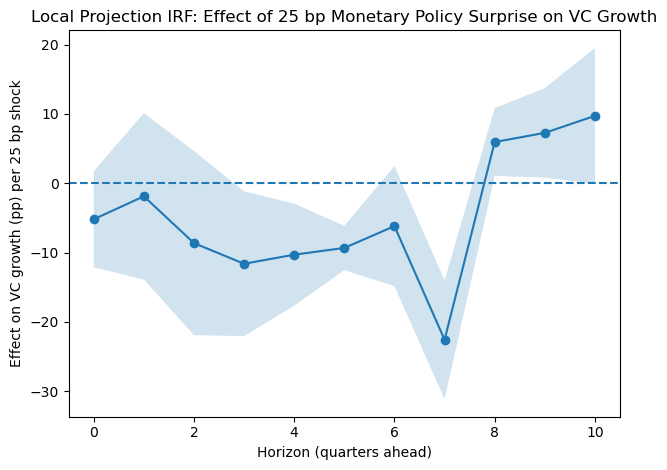

In [11]:
# plot IRF data
x = irf["horizon_q"].values
yb = irf["beta_mps25"].values
lo = irf["ci90_low"].values
hi = irf["ci90_high"].values

# create plot
plt.figure()

plt.plot(x, yb, marker="o")
plt.fill_between(x, lo, hi, alpha=0.2) # 90% CI band
plt.axhline(0, linestyle="--")
plt.xlabel("Horizon (quarters ahead)")
plt.ylabel("Effect on VC growth (pp) per 25 bp shock")
plt.title("Local Projection IRF: Effect of 25 bp Monetary Policy Surprise on VC Growth")
plt.tight_layout()
plt.show()


In [4]:
# Local Projection Model (Cumulative)
H = 10 
rows = []

for h in range(H + 1):
    # CHANGE: Sum growth from t to t+h for cumulative effect
    # This represents: log(Level_{t+h}) - log(Level_{t-1})
    y = df[y_col].rolling(window=h+1).sum().shift(-h)

    # RHS stays the same (anchored at time of shock/pre-shock)
    X = df[[shock_col, spread_col, nasdaq_col]].copy()
    X = sm.add_constant(X)

    data = pd.concat([y, X], axis=1).dropna()

    if len(data) < 10:
        rows.append({"horizon_q": h, "beta_mps25": np.nan, "N": len(data)})
        continue

    y_a = data[y_col]
    X_a = data.drop(columns=[y_col])

    # Newey-West handles the serial correlation inherent in cumulative data
    res = sm.OLS(y_a, X_a).fit(cov_type="HAC", cov_kwds={"maxlags": h})

    b = res.params.get(shock_col, np.nan)
    se = res.bse.get(shock_col, np.nan)
    
    rows.append({
        "horizon_q": h,
        "beta_mps25": b,
        "se": se,
        "p": res.pvalues.get(shock_col, np.nan),
        "ci90_low": b - 1.645 * se,
        "ci90_high": b + 1.645 * se,
        "N": int(res.nobs)
    })

irf_cum = pd.DataFrame(rows)

In [5]:
irf_cum

,horizon_q,beta_mps25,se,p,ci90_low,ci90_high,N
0,0,-5.196338,5.307841,0.327583,-13.927736,3.535060,34
1,1,-6.498900,10.550452,0.537906,-23.854393,10.856593,33
2,2,-13.042664,16.358011,0.425262,-39.951592,13.866264,32
3,3,-24.890512,20.138038,0.216460,-58.017584,8.236561,31
4,4,-35.164587,24.219449,0.146525,-75.005581,4.676406,30
5,5,-41.525333,26.370658,0.115330,-84.905065,1.854399,29
6,6,-40.853874,25.495990,0.109075,-82.794777,1.087030,28
7,7,-44.134076,11.663301,0.000154,-63.320206,-24.947946,27
8,8,-31.646234,7.352796,0.000017,-43.741583,-19.550884,26
9,9,-20.923389,6.859573,0.002287,-32.207387,-9.639392,25


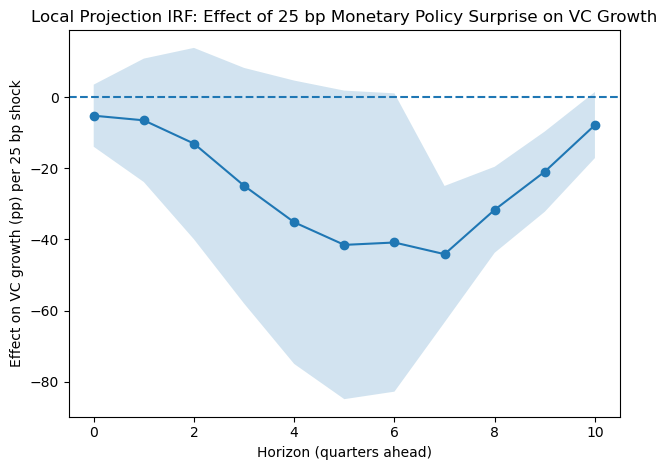

In [6]:
# plot IRF data
x = irf_cum["horizon_q"].values
yb = irf_cum["beta_mps25"].values
lo = irf_cum["ci90_low"].values
hi = irf_cum["ci90_high"].values

# create plot
plt.figure()

plt.plot(x, yb, marker="o")
plt.fill_between(x, lo, hi, alpha=0.2) # 90% CI band
plt.axhline(0, linestyle="--")
plt.xlabel("Horizon (quarters ahead)")
plt.ylabel("Effect on VC growth (pp) per 25 bp shock")
plt.title("Local Projection IRF: Effect of 25 bp Monetary Policy Surprise on VC Growth")
plt.tight_layout()
plt.show()